# Site frequency spectrum analysis

End-to-end pipeline to produce the GC-normalized, ancestral-allele-polarized WS/SW ratio plot at TSS regions, comparing against intergenic controls, recombination hotspots, exons, and introns.

**Pipeline:**
1. **Setup** — imports, paths, constants.
2. **Extract allele frequencies from gnomAD** (Hail) — produces per-region TSV files. *Skip if these already exist.*
3. **Annotate variants by region** (exon vs intron splits) — uses gene annotation + GTF to drop transcripts where exon 2+ falls in the window.
4. **Annotate variants with ancestral allele** — Ensembl EPO inferred ancestor; needed to polarize derived allele frequency correctly.
5. **Load polarized arrays** — caches to NPZ on first run.
6. **GC content computation** — strand-aware exon/intron BED building, then `bedtools nuc`.
7. **Final WS/SW ratio plot** — GC-normalized, log-x derived allele frequency.


## 1. Setup

Run every time.

In [10]:
# --- Imports ---
import os
import ast
import gzip
import re
import csv
from collections import Counter, defaultdict
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

print("Imports done.")

Imports done.


In [11]:
# --- Configuration: paths, labels, constants ---

# Working directory for all outputs
os.makedirs('bedfiles', exist_ok=True)
os.makedirs('ancestor', exist_ok=True)

# Input BED files defining the regions of interest (1-based, with 'chr' prefix)
BED_FILES = {
    'intergenic':  'bedfiles/human_intergenic_random_5kb.bed',
    'TSS':         'bedfiles/Fantom5_CAGE_hg38_gencode.v40_TSS_-150_+350.bed',
    'recomb':      'bedfiles/decode_recombAvg_hotspots_hg38_100.bed',
}

# Per-region variant TSVs to be produced by Hail (one row per variant)
VARIANT_TSVS = {
    'intergenic':  'bedfiles/human_intergenic_random_5kb.tsv',
    'TSS':         'bedfiles/Fantom5_CAGE_hg38_gencode.v40_TSS_-150_+350.tsv',
    'recomb':      'bedfiles/decode_recombAvg_hotspots_hg38_100.tsv',
}

# Per-region AA-annotated TSVs (produced from VARIANT_TSVS by adding an aa column)
intergenic_file = 'bedfiles/human_intergenic_random_5kb.aa.tsv'
filenames = [
    'bedfiles/Fantom5_CAGE_hg38_gencode.v40_TSS_-150_+350.aa.tsv',
    'bedfiles/decode_recombAvg_hotspots_hg38_100.aa.tsv',
    'bedfiles/Fantom5_CAGE_hg38_gencode.v40_TSS_-150_+350_annotated_exon.aa.tsv',
    'bedfiles/Fantom5_CAGE_hg38_gencode.v40_TSS_-150_+350_annotated_intron.aa.tsv',
]

# Labels / colors / markers (order matches `filenames`)
window_labels    = ['TSS -150/+350', 'Recombination Germline', 'Exon', 'Intron']
window_colors    = ['#2196F3', '#E53935', '#FFAE00', '#9D2BD6']
window_markers   = ['o', 's', 'o', 'o']
intergenic_color = '#4CAF50'

# Reference resources — EDIT THESE PATHS for your machine
GENE_ANNOTATION_TSV = '/home/alexpalazzo1/Documents/Tina/Rare_SNP/Fantom5_CAGE_hg38_gencode.v40_TSS_EIB_Updated_200.txt'
GTF_PATH            = '/home/alexpalazzo1/Documents/Tina/Rare_SNP/gencode.v40.annotation.gtf'
GENOME_FASTA        = '/media/alexpalazzo1/ohta/Tina/SNPs_and_Indels/PrimateSNPs/Homo_sapiens.GRCh38.dna.toplevel.fa'
ANCESTOR_DIR        = 'ancestor/homo_sapiens_ancestor_GRCh38'

# Window bounds and constants
UPSTREAM_BP, DOWNSTREAM_BP = 150, 350
TWO_N = 152000     # gnomAD v3 sample size

# Cache file for parsed/polarized arrays — versioned name so changes invalidate
NPZ_FILE = 'sfs_data_polarized.npz'

print("Config set.")

Config set.


In [4]:
# --- SW / WS mutation classes (ancestral -> derived direction) ---
SW_MUTATIONS = {('G','A'), ('G','T'), ('C','A'), ('C','T')}
WS_MUTATIONS = {('A','C'), ('A','G'), ('T','C'), ('T','G')}

def parse_af(value):
    '''Parse AF field. Handles plain float and list-encoded strings like "[0.3]".'''
    value = value.strip()
    try:
        return float(value)
    except ValueError:
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list) and len(parsed) > 0:
                return float(parsed[0])
        except (ValueError, SyntaxError):
            return None
    return None

print("Constants and helpers defined.")

Constants and helpers defined.


## 2. Extract allele frequencies from gnomAD with Hail

Skip this whole section if the per-region TSVs at the paths in `VARIANT_TSVS` already exist on disk. Each call streams the gnomAD v3.1.1 sites Hail Table from GCS, filters to a single BED interval set, and exports a TSV with columns: `locus  alleles  chromosome  position  af  ac  an`.

**One-time downloads required:**
- gnomAD GCS service-account JSON (for GCS authentication)
- BED files for each region (intergenic, TSS, recombination hotspots)
- The `gcs-connector-hadoop3-latest.jar` (referenced in spark_conf below)

**Performance note:** Filtering to BED intervals first is the biggest data-reduction step. Each region typically takes 10–60 minutes depending on connection speed.

In [ ]:
# Run this cell once per region to produce the variant TSVs.
# If the output TSVs already exist, you can skip this entire cell.

def run_hail_extraction(bed_file, output_file,
                       gcs_jar='/home/alexpalazzo1/hail/jars/gcs-connector-hadoop3-latest.jar',
                       gcs_keyfile='/home/alexpalazzo1/hail/gnomad-hail-439921-1ae1364a1b5a.json'):
    '''Stream gnomAD v3.1.1 sites HT, filter to BED intervals, export AF/AC/AN per variant.'''
    import hail as hl

    hl.init(
        master='local[32]',
        spark_conf={
            'spark.jars': f'file://{gcs_jar}',
            'spark.hadoop.google.cloud.auth.service.account.enable': 'true',
            'spark.hadoop.google.cloud.auth.service.account.json.keyfile': gcs_keyfile,
            'spark.hadoop.fs.gs.impl': 'com.google.cloud.hadoop.fs.gcs.GoogleHadoopFileSystem',
            'spark.hadoop.fs.AbstractFileSystem.gs.impl': 'com.google.cloud.hadoop.fs.gcs.GoogleHadoopFS',
            'spark.driver.memory': '48g',
            'spark.executor.memory': '48g',
            'spark.driver.maxResultSize': '8g',
            'spark.memory.fraction': '0.8',
            'spark.memory.storageFraction': '0.3',
            'spark.default.parallelism': '128',
            'spark.sql.shuffle.partitions': '128',
            'spark.hadoop.fs.gs.io.buffersize': '8388608',
            'spark.hadoop.fs.gs.block.size': '134217728',
            'spark.hadoop.fs.gs.http.max.retry': '10',
            'spark.serializer': 'org.apache.spark.serializer.KryoSerializer',
            'spark.kryoserializer.buffer.max': '1g',
        },
    )

    GNOMAD_HT = 'gs://gcp-public-data--gnomad/release/3.1.1/ht/genomes/gnomad.genomes.v3.1.1.sites.ht'
    print(f"Loading BED: {bed_file}")
    bed = hl.import_bed(bed_file, reference_genome='GRCh38')
    bed = bed.filter(bed.interval.start.contig != 'chrMT')

    print("Reading gnomAD HT...")
    ht = hl.read_table(GNOMAD_HT)

    # Filter: BED -> SNPs only -> PASS -> AF > 0
    ht = ht.filter(hl.is_defined(bed[ht.locus]))
    ht = ht.filter(hl.is_snp(ht.alleles[0], ht.alleles[1]))
    ht = ht.filter(hl.len(ht.filters) == 0)
    ht = ht.filter(ht.freq[0].AF > 0.0)

    ht = ht.checkpoint('/tmp/hail_gnomad_checkpoint.ht', overwrite=True)
    ht = ht.select(
        chromosome = ht.locus.contig,
        position   = ht.locus.position,
        af         = ht.freq[0].AF,
        ac         = ht.freq[0].AC,
        an         = ht.freq[0].AN,
    )
    ht.export(output_file)
    print(f"Wrote {output_file}")
    hl.stop()


# Uncomment and run for each region as needed:
# for tag, bed_path in BED_FILES.items():
#     out_path = VARIANT_TSVS[tag]
#     if os.path.exists(out_path):
#         print(f"Skipping {tag}: {out_path} already exists")
#         continue
#     run_hail_extraction(bed_path, out_path)

## 3. Annotate TSS variants by region (exon / intron / intergenic)

The TSS window contains the first exon, first intron, and a 150-bp upstream flank. To analyze them separately, classify each variant as *exon*, *intron*, or *intergenic* based on its position relative to TSS and the first exon/intron boundary (FEIB), strand-aware.

**Filtering:** transcripts whose exon 2 (or later) overlaps the TSS+downstream window are excluded — otherwise variants in those late exons contaminate the "intron" bucket. This requires a GENCODE-style GTF.

The functions below are equivalent to running `annotate_variants.py --gtf ...` from the command line.

In [12]:
# --- Region-classification logic (embedded; same as annotate_variants.py) ---

def find_transcripts_with_downstream_exons(gtf_path, annotations, downstream_bp):
    '''Return version-stripped transcript IDs whose exon 2+ overlaps the
    [TSS+1, TSS+downstream] window (strand-aware).'''
    ann_tx_base = (annotations['Ensembl_Transcript_ID']
                   .astype(str).str.replace(r'\.\d+$', '', regex=True))
    target_tx = set(ann_tx_base)

    opener = gzip.open if gtf_path.endswith('.gz') else open
    tx_exons = defaultdict(list)
    tx_re  = re.compile(r'transcript_id "([^"]+)"')
    num_re = re.compile(r'exon_number (\d+)')
    with opener(gtf_path, 'rt') as f:
        for line in f:
            if line.startswith('#'): continue
            fields = line.rstrip('\n').split('\t')
            if len(fields) < 9 or fields[2] != 'exon': continue
            m = tx_re.search(fields[8])
            if not m: continue
            tx_id = m.group(1).split('.')[0]
            if tx_id not in target_tx: continue
            mnum = num_re.search(fields[8])
            tx_exons[tx_id].append({
                'start': int(fields[3]),
                'end':   int(fields[4]),
                'exon_number': int(mnum.group(1)) if mnum else None,
            })

    tx_to_row = {base: row for (_, row), base in zip(annotations.iterrows(), ann_tx_base)}
    bad_tx = set()
    for tx_id, exons in tx_exons.items():
        if len(exons) < 2 or tx_id not in tx_to_row: continue
        row = tx_to_row[tx_id]
        tss = int(row['Transcriptional_Start_Site'])
        strand = row['Strand']
        if all(e['exon_number'] is not None for e in exons):
            exons_sorted = sorted(exons, key=lambda e: e['exon_number'])
        elif strand == '+':
            exons_sorted = sorted(exons, key=lambda e: e['start'])
        else:
            exons_sorted = sorted(exons, key=lambda e: -e['end'])
        if strand == '+':
            win_lo, win_hi = tss + 1, tss + downstream_bp
        else:
            win_lo, win_hi = tss - downstream_bp, tss - 1
        for e in exons_sorted[1:]:
            if e['start'] <= win_hi and e['end'] >= win_lo:
                bad_tx.add(tx_id)
                break
    return bad_tx


def build_index(annotations, upstream, downstream):
    '''Per-chromosome window index for fast lookup.'''
    idx = {}
    for chrom, sub in annotations.groupby('Chromosome'):
        sub = sub.reset_index(drop=True).copy()
        tss = sub['Transcriptional_Start_Site'].to_numpy()
        plus = (sub['Strand'].to_numpy() == '+')
        window_lo = np.where(plus, tss - upstream,   tss - downstream)
        window_hi = np.where(plus, tss + downstream, tss + upstream)
        sub['_window_lo'] = window_lo
        sub['_window_hi'] = window_hi
        order = np.argsort(window_lo)
        sub = sub.iloc[order].reset_index(drop=True)
        idx[chrom] = {
            'genes':     sub,
            'window_lo': sub['_window_lo'].to_numpy(),
            'window_hi': sub['_window_hi'].to_numpy(),
        }
    return idx


def classify_variant_pos(pos, chrom_idx):
    if chrom_idx is None:
        return ('intergenic', '', '')
    genes = chrom_idx['genes']
    window_lo = chrom_idx['window_lo']
    window_hi = chrom_idx['window_hi']
    j = np.searchsorted(window_lo, pos, side='right')
    candidate_mask = window_hi[:j] >= pos
    candidate_idxs = np.nonzero(candidate_mask)[0]
    if len(candidate_idxs) == 0:
        return ('intergenic', '', '')
    if len(candidate_idxs) == 1:
        g = genes.iloc[candidate_idxs[0]]
    else:
        sub = genes.iloc[candidate_idxs]
        dist = sub['Transcriptional_Start_Site'].to_numpy() - pos
        g = sub.iloc[int(np.argmin(np.abs(dist)))]
    tss = int(g['Transcriptional_Start_Site'])
    feib = int(g['First_Exon_Intron_Boundary'])
    strand = g['Strand']
    if strand == '+':
        if pos < tss: region = 'intergenic'
        elif pos <= feib: region = 'exon'
        else: region = 'intron'
    else:
        if pos > tss: region = 'intergenic'
        elif pos >= feib: region = 'exon'
        else: region = 'intron'
    return (region, str(g['Ensembl_Gene_ID']), str(g['Ensembl_Transcript_ID']))


def annotate_tss_variants_with_region(variants_tsv, annotation_tsv, gtf_path, out_tsv,
                                       upstream=UPSTREAM_BP, downstream=DOWNSTREAM_BP):
    '''
    Annotate variants with region (exon/intron/intergenic) and gene/transcript IDs.
    Drops transcripts whose exon 2+ overlaps the downstream window. Splits output into
    {out}.exon.tsv, {out}.intron.tsv, {out}.intergenic.tsv.
    '''
    print(f"Loading variants and annotations...")
    variants = pd.read_csv(variants_tsv, sep='\t')
    annotations = pd.read_csv(annotation_tsv, sep='\t')

    print(f"Filtering transcripts via GTF ({gtf_path})...")
    bad_tx = find_transcripts_with_downstream_exons(gtf_path, annotations, downstream)
    before = len(annotations)
    ann_tx_base = (annotations['Ensembl_Transcript_ID']
                   .astype(str).str.replace(r'\.\d+$', '', regex=True))
    annotations = annotations[~ann_tx_base.isin(bad_tx)].reset_index(drop=True)
    print(f"  Excluded {before - len(annotations):,} / {before:,} transcripts.")

    print(f"Classifying {len(variants):,} variants...")
    index = build_index(annotations, upstream, downstream)
    regions, gids, tids = [], [], []
    for chrom, pos in zip(variants['chromosome'], variants['position']):
        r, gid, tid = classify_variant_pos(int(pos), index.get(chrom))
        regions.append(r); gids.append(gid); tids.append(tid)
    out = variants.copy()
    out['region'] = regions
    out['Ensembl_Gene_ID'] = gids
    out['Ensembl_Transcript_ID'] = tids

    # Drop variants whose only home gene was excluded
    before_v = len(out)
    out = out[out['Ensembl_Gene_ID'] != ''].reset_index(drop=True)
    print(f"  Dropped {before_v - len(out):,} variants outside any kept gene's window.")

    out.to_csv(out_tsv, sep='\t', index=False, quoting=csv.QUOTE_NONE)
    print(f"\nWrote {len(out):,} rows -> {out_tsv}")
    print(out['region'].value_counts().to_string())

    base, ext = os.path.splitext(out_tsv)
    for region in ('intergenic', 'exon', 'intron'):
        subset = out[out['region'] == region]
        path = f"{base}.{region}{ext}"
        subset.to_csv(path, sep='\t', index=False, quoting=csv.QUOTE_NONE)
        print(f"  {region}: {len(subset):,} rows -> {path}")


# Run on the TSS variants file. Skip if the exon/intron splits already exist.
exon_split  = VARIANT_TSVS['TSS'].replace('.tsv', '_annotated.exon.tsv')
intron_split = VARIANT_TSVS['TSS'].replace('.tsv', '_annotated.intron.tsv')
if not (os.path.exists(exon_split) and os.path.exists(intron_split)):
    annotate_tss_variants_with_region(
        variants_tsv   = VARIANT_TSVS['TSS'],
        annotation_tsv = GENE_ANNOTATION_TSV,
        gtf_path       = GTF_PATH,
        out_tsv        = VARIANT_TSVS['TSS'].replace('.tsv', '_annotated.tsv'),
    )
else:
    print(f"Region splits already exist; skipping.")

Loading variants and annotations...
Filtering transcripts via GTF (/home/alexpalazzo1/Documents/Tina/Rare_SNP/gencode.v40.annotation.gtf)...
  Excluded 923 / 17,112 transcripts.
Classifying 2,427,251 variants...
  Dropped 124,139 variants outside any kept gene's window.

Wrote 2,303,112 rows -> bedfiles/Fantom5_CAGE_hg38_gencode.v40_TSS_-150_+350_annotated.tsv
region
exon          947532
intergenic    742912
intron        612668
  intergenic: 742,912 rows -> bedfiles/Fantom5_CAGE_hg38_gencode.v40_TSS_-150_+350_annotated.intergenic.tsv
  exon: 947,532 rows -> bedfiles/Fantom5_CAGE_hg38_gencode.v40_TSS_-150_+350_annotated.exon.tsv
  intron: 612,668 rows -> bedfiles/Fantom5_CAGE_hg38_gencode.v40_TSS_-150_+350_annotated.intron.tsv


## 4. Annotate variants with ancestral allele (Ensembl EPO)

The "alt" allele in gnomAD is *not* the derived allele — it's just whatever differs from the GRCh38 reference. At ~1% of sites genome-wide (and ~70% of sites at alt-AF > 50%), the reference happens to carry the derived allele, so the ref/alt convention is backwards relative to ancestral/derived.

To polarize correctly, look up each variant in the **Ensembl EPO inferred primate ancestor** (Paten et al. 2008, Genome Research). Adds an `aa` column to each TSV; rows where the ancestor is unknown or low-confidence get an empty `aa` and are dropped downstream.

**Citations:** Paten et al. 2008 (10.1101/gr.076554.108 and 10.1101/gr.076521.108); Herrero et al. 2016 (10.1093/database/bav096).

In [ ]:
%%bash
# One-time download of the Ensembl ancestral FASTA. ~250 MB compressed.
# Skip if `ancestor/homo_sapiens_ancestor_GRCh38/` already exists.
cd ancestor
if [ ! -d homo_sapiens_ancestor_GRCh38 ]; then
    wget -q https://ftp.ensembl.org/pub/release-112/fasta/ancestral_alleles/homo_sapiens_ancestor_GRCh38.tar.gz
    tar xzf homo_sapiens_ancestor_GRCh38.tar.gz
    echo "Extracted:"
    ls homo_sapiens_ancestor_GRCh38/ | head
else
    echo "Already downloaded."
fi

In [13]:
# AA lookup setup. Requires:  pip install pyfaidx
import pyfaidx

_anc_cache = {}

def _anc_record(chrom):
    '''Accept "chr1", "1", "chrX", "MT" — all map to homo_sapiens_ancestor_<chrom>.fa.'''
    c = chrom[3:] if chrom.startswith('chr') else chrom
    if c == 'M': c = 'MT'
    if c in _anc_cache:
        return _anc_cache[c]
    path = os.path.join(ANCESTOR_DIR, f'homo_sapiens_ancestor_{c}.fa')
    if not os.path.exists(path):
        _anc_cache[c] = None
        return None
    fa = pyfaidx.Fasta(path, sequence_always_upper=False)
    rec = fa[list(fa.keys())[0]]
    _anc_cache[c] = rec
    return rec

def lookup_aa(chrom, pos_1based, high_confidence_only=True):
    '''
    Return ancestral base or None.
    high_confidence_only=True keeps only uppercase calls (EPO consensus across
    all 6 primates). Lowercase, '-', 'N', '.' return None.
    '''
    rec = _anc_record(chrom)
    if rec is None: return None
    try:
        b = str(rec[pos_1based - 1])
    except (IndexError, KeyError):
        return None
    if high_confidence_only:
        return b if b in 'ACGT' else None
    return b if b.upper() in 'ACGT' else None

def annotate_tsv_with_aa(in_path, out_path, list_format=True):
    '''Append an `aa` column. Empty string for low-confidence/missing.'''
    n, n_no, n_low = 0, 0, 0
    with open(in_path) as f_in, open(out_path, 'w') as f_out:
        header = next(f_in).rstrip('\n')
        f_out.write(header + '\taa\n')
        for line in f_in:
            cols = line.rstrip('\n').split('\t')
            if len(cols) < 4: continue
            chrom = cols[2]
            try: pos = int(cols[3])
            except ValueError: continue
            aa = lookup_aa(chrom, pos, high_confidence_only=True)
            if aa is None:
                aa_any = lookup_aa(chrom, pos, high_confidence_only=False)
                if aa_any is None: n_no += 1
                else: n_low += 1
                aa_out = ''
            else:
                aa_out = aa
            f_out.write(line.rstrip('\n') + '\t' + aa_out + '\n')
            n += 1
    print(f"  {in_path} -> {out_path}")
    print(f"    rows: {n:,}   no AA: {n_no:,} ({100*n_no/n:.1f}%)   "
          f"low-confidence: {n_low:,} ({100*n_low/n:.1f}%)")


# Annotate every input TSV. The intergenic file uses list_format=True
# (its AF field is bracketed), the others are plain floats.
def _src_of(aa_path):
    return aa_path.replace('.aa.tsv', '.tsv')

if not os.path.exists(intergenic_file):
    annotate_tsv_with_aa(_src_of(intergenic_file), intergenic_file, list_format=True)
else:
    print(f"Skipping {intergenic_file} (already exists)")

for fn in filenames:
    if not os.path.exists(fn):
        annotate_tsv_with_aa(_src_of(fn), fn, list_format=False)
    else:
        print(f"Skipping {fn} (already exists)")

Skipping bedfiles/human_intergenic_random_5kb.aa.tsv (already exists)
Skipping bedfiles/Fantom5_CAGE_hg38_gencode.v40_TSS_-150_+350.aa.tsv (already exists)
Skipping bedfiles/decode_recombAvg_hotspots_hg38_100.aa.tsv (already exists)
Skipping bedfiles/Fantom5_CAGE_hg38_gencode.v40_TSS_-150_+350_annotated_exon.aa.tsv (already exists)
Skipping bedfiles/Fantom5_CAGE_hg38_gencode.v40_TSS_-150_+350_annotated_intron.aa.tsv (already exists)


## 5. Load polarized SW/WS arrays

For each variant: compare ref/alt to ancestral. If `ref == aa`, the alt is derived (DAF = alt-AF). If `alt == aa`, the ref is derived (DAF = 1 − alt-AF, the variant has been "flipped"). Otherwise (no AA, or AA matches neither) drop. Also drop S↔S and W↔W changes which aren't informative for gBGC.

First run parses all five TSVs and caches to `sfs_data_polarized.npz`. Subsequent runs load the cache instantly. **Delete the NPZ if you change the polarization logic upstream.**

In [14]:
def load_daf_by_mutation_type(filename, list_format=False):
    '''
    Return {'SW': np.array of DAFs, 'WS': np.array of DAFs}.
    Drops: no-AA, AA-matches-neither (triallelic), S<->S, W<->W.
    '''
    sw, ws = [], []
    stats = Counter()
    with open(filename) as f:
        header = next(f).rstrip('\n').split('\t')
        try:
            aa_idx = header.index('aa')
        except ValueError:
            raise ValueError(f"{filename}: no 'aa' column. Re-run annotation.")
        for line in f:
            cols = line.rstrip('\n').split('\t')
            if len(cols) <= aa_idx: continue
            aa = cols[aa_idx].strip().upper()
            if aa == '' or aa not in 'ACGT':
                stats['no_aa'] += 1; continue
            try:
                alleles = ast.literal_eval(cols[1])
                ref, alt = alleles[0].upper(), alleles[1].upper()
                af = parse_af(cols[4]) if list_format else float(cols[4])
                if af is None or not (0 < af <= 1.0): continue
            except (ValueError, IndexError, SyntaxError):
                continue

            if aa == ref and aa != alt:
                anc, der, daf = ref, alt, af
                stats['ref_anc'] += 1
            elif aa == alt and aa != ref:
                anc, der, daf = alt, ref, 1.0 - af
                stats['alt_anc_flipped'] += 1
            else:
                stats['aa_matches_neither'] += 1; continue

            pair = (anc, der)
            if pair in SW_MUTATIONS: sw.append(daf)
            elif pair in WS_MUTATIONS: ws.append(daf)
            else: stats['SS_or_WW'] += 1

    print(f"  {filename}")
    print(f"    SW: {len(sw):>10,} | WS: {len(ws):>10,}")
    print(f"    kept ref=anc: {stats['ref_anc']:>10,}   re-polarized alt=anc: {stats['alt_anc_flipped']:>7,}")
    print(f"    dropped  no-AA: {stats['no_aa']:,}   AA-mismatch: {stats['aa_matches_neither']:,}   "
          f"S<->S / W<->W: {stats['SS_or_WW']:,}")
    return {'SW': np.array(sw), 'WS': np.array(ws)}


if os.path.exists(NPZ_FILE):
    print(f"Found {NPZ_FILE} — loading cached arrays.")
    d = np.load(NPZ_FILE)
    ig_data = {'SW': d['ig_SW'], 'WS': d['ig_WS']}
    tss_data = [
        {'SW': d[f'tss{i}_SW'], 'WS': d[f'tss{i}_WS']}
        for i in range(len(filenames))
    ]
else:
    print("Loading from TSV files (slow on first run)...")
    print("Loading intergenic...")
    ig_data = load_daf_by_mutation_type(intergenic_file, list_format=True)
    tss_data = []
    for fn, label in zip(filenames, window_labels):
        print(f"Loading {label}...")
        tss_data.append(load_daf_by_mutation_type(fn, list_format=False))
    save_dict = {'ig_SW': ig_data['SW'], 'ig_WS': ig_data['WS']}
    for i, d in enumerate(tss_data):
        save_dict[f'tss{i}_SW'] = d['SW']
        save_dict[f'tss{i}_WS'] = d['WS']
    np.savez(NPZ_FILE, **save_dict)
    print(f"\nSaved cache ({os.path.getsize(NPZ_FILE)/1024/1024:.1f} MB).")

print("\nLoaded:")
print(f"  Intergenic           SW: {len(ig_data['SW']):>9,} | WS: {len(ig_data['WS']):>9,}")
for i, label in enumerate(window_labels):
    print(f"  {label:<22s} SW: {len(tss_data[i]['SW']):>9,} | WS: {len(tss_data[i]['WS']):>9,}")

Found sfs_data_polarized.npz — loading cached arrays.

Loaded:
  Intergenic           SW: 4,551,398 | WS: 3,954,520
  TSS -150/+350          SW: 1,246,051 | WS:   384,674
  Recombination Germline SW:   586,712 | WS:   457,659
  Exon                   SW:   486,688 | WS:   138,914
  Intron                 SW:   320,434 | WS:   105,291


## 6. GC content per region

To normalize the WS/SW ratio for mutation opportunity, compute `n_S/n_W` — the ratio of GC bases to AT bases — in each region using `bedtools nuc` against the GRCh38 reference.

For exon and intron portions of the TSS window specifically, build strand-aware sub-interval BEDs first (the same gene-set filtering as in Step 3 applies, so transcripts with exon 2+ in the window are excluded).

In [15]:
# Build exon-portion and intron-portion BEDs for the TSS window.

ann = pd.read_csv(GENE_ANNOTATION_TSV, sep='\t')
print(f"Loaded {len(ann):,} annotation rows")

# Apply the same GTF filter as Step 3 so the GC denominator matches the variant set.
if GTF_PATH is not None:
    ann_tx_base = ann['Ensembl_Transcript_ID'].astype(str).str.replace(r'\.\d+$', '', regex=True)
    target_tx = set(ann_tx_base)
    opener = gzip.open if GTF_PATH.endswith('.gz') else open
    tx_exons = defaultdict(list)
    tx_re  = re.compile(r'transcript_id "([^"]+)"')
    num_re = re.compile(r'exon_number (\d+)')
    with opener(GTF_PATH, 'rt') as f:
        for line in f:
            if line.startswith('#'): continue
            fields = line.rstrip('\n').split('\t')
            if len(fields) < 9 or fields[2] != 'exon': continue
            m = tx_re.search(fields[8])
            if not m: continue
            tx_id = m.group(1).split('.')[0]
            if tx_id not in target_tx: continue
            mnum = num_re.search(fields[8])
            tx_exons[tx_id].append({
                'start': int(fields[3]),
                'end':   int(fields[4]),
                'exon_number': int(mnum.group(1)) if mnum else None,
            })
    tx_to_row = {base: row for (_, row), base in zip(ann.iterrows(), ann_tx_base)}
    bad_tx = set()
    for tx_id, exons in tx_exons.items():
        if len(exons) < 2 or tx_id not in tx_to_row: continue
        row = tx_to_row[tx_id]
        tss    = int(row['Transcriptional_Start_Site'])
        strand = row['Strand']
        if all(e['exon_number'] is not None for e in exons):
            exons_sorted = sorted(exons, key=lambda e: e['exon_number'])
        elif strand == '+':
            exons_sorted = sorted(exons, key=lambda e: e['start'])
        else:
            exons_sorted = sorted(exons, key=lambda e: -e['end'])
        if strand == '+':
            win_lo, win_hi = tss + 1, tss + DOWNSTREAM_BP
        else:
            win_lo, win_hi = tss - DOWNSTREAM_BP, tss - 1
        for e in exons_sorted[1:]:
            if e['start'] <= win_hi and e['end'] >= win_lo:
                bad_tx.add(tx_id)
                break
    before = len(ann)
    ann = ann[~ann_tx_base.isin(bad_tx)].reset_index(drop=True)
    print(f"Excluded {before - len(ann):,} / {before:,} transcripts.")

# Build BED rows for exon and intron portions of the window.
exon_rows, intron_rows = [], []
for _, g in ann.iterrows():
    chrom   = str(g['Chromosome'])
    tss     = int(g['Transcriptional_Start_Site'])
    feib    = int(g['First_Exon_Intron_Boundary'])
    strand  = g['Strand']
    gene_id = g['Ensembl_Gene_ID']
    if strand == '+':
        win_lo, win_hi = tss - UPSTREAM_BP, tss + DOWNSTREAM_BP
        exon_lo, exon_hi = tss, min(feib, win_hi)
        if feib < win_hi:
            intron_lo, intron_hi = max(feib + 1, win_lo), win_hi
        else:
            intron_lo = intron_hi = None
    else:
        win_lo, win_hi = tss - DOWNSTREAM_BP, tss + UPSTREAM_BP
        exon_lo, exon_hi = max(feib, win_lo), tss
        if feib > win_lo:
            intron_lo, intron_hi = win_lo, min(feib - 1, win_hi)
        else:
            intron_lo = intron_hi = None
    # Strip 'chr' prefix; remap M -> MT (matches the Ensembl-style FASTA)
    c = chrom[3:] if chrom.startswith('chr') else chrom
    if c == 'M': c = 'MT'
    if exon_lo <= exon_hi:
        exon_rows.append((c, exon_lo - 1, exon_hi, gene_id))   # BED 0-based half-open
    if intron_lo is not None and intron_lo <= intron_hi:
        intron_rows.append((c, intron_lo - 1, intron_hi, gene_id))

with open('bedfiles/exon_window_nochr.bed', 'w') as f:
    for r in exon_rows: f.write(f"{r[0]}\t{r[1]}\t{r[2]}\t{r[3]}\n")
with open('bedfiles/intron_window_nochr.bed', 'w') as f:
    for r in intron_rows: f.write(f"{r[0]}\t{r[1]}\t{r[2]}\t{r[3]}\n")

print(f"\nWrote {len(exon_rows):,} exon intervals  ({sum(r[2]-r[1] for r in exon_rows):,} bp)")
print(f"Wrote {len(intron_rows):,} intron intervals ({sum(r[2]-r[1] for r in intron_rows):,} bp)")

Loaded 17,112 annotation rows
Excluded 923 / 17,112 transcripts.

Wrote 16,189 exon intervals  (3,253,109 bp)
Wrote 12,460 intron intervals (2,429,230 bp)


In [16]:
%%bash
# Strip 'chr' prefix from full-window BEDs so they match the Ensembl-style FASTA.
for src in 'Fantom5_CAGE_hg38_gencode.v40_TSS_-150_+350.bed' \
           'decode_recombAvg_hotspots_hg38_100.bed' \
           'human_intergenic_random_5kb.bed'; do
    dst=$(echo $src | sed 's/\.bed$/_nochr.bed/')
    if [ -f bedfiles/$src ]; then
        sed 's/^chrM\t/MT\t/; s/^chr//' bedfiles/$src > bedfiles/$dst
        echo "wrote bedfiles/$dst"
    else
        echo "skip: bedfiles/$src not found"
    fi
done

wrote bedfiles/Fantom5_CAGE_hg38_gencode.v40_TSS_-150_+350_nochr.bed
wrote bedfiles/decode_recombAvg_hotspots_hg38_100_nochr.bed
wrote bedfiles/human_intergenic_random_5kb_nochr.bed


In [17]:
%%bash
# Run bedtools nuc against the genome FASTA. Edit GENOME path if needed.
GENOME=/media/alexpalazzo1/ohta/Tina/SNPs_and_Indels/PrimateSNPs/Homo_sapiens.GRCh38.dna.toplevel.fa

bedtools nuc -fi $GENOME -bed bedfiles/exon_window_nochr.bed   > bedfiles/gc_exon.txt
bedtools nuc -fi $GENOME -bed bedfiles/intron_window_nochr.bed > bedfiles/gc_intron.txt
bedtools nuc -fi $GENOME -bed bedfiles/Fantom5_CAGE_hg38_gencode.v40_TSS_-150_+350_nochr.bed > bedfiles/gc_TSS.txt
bedtools nuc -fi $GENOME -bed bedfiles/decode_recombAvg_hotspots_hg38_100_nochr.bed         > bedfiles/gc_recomb.txt
bedtools nuc -fi $GENOME -bed bedfiles/human_intergenic_random_5kb_nochr.bed                > bedfiles/gc_intergenic.txt

echo "Done."
head -3 bedfiles/gc_TSS.txt

Done.
#1_usercol	2_usercol	3_usercol	4_usercol	5_usercol	6_usercol	7_pct_at	8_pct_gc	9_num_A	10_num_C	11_num_G	12_num_T	13_num_N	14_num_oth	15_seq_len
1	958906	959406	ENSG00000188976	ENST00000327044	-	0.302000	0.698000	80	207	142	71	0	0	500
1	999747	1000247	ENSG00000188290	ENST00000304952	-	0.230000	0.770000	39	212	173	76	0	0	500


In [18]:
def parse_bedtools_nuc(gc_file):
    '''Parse bedtools nuc output to get total W (AT) and S (GC) base counts.'''
    df = pd.read_csv(gc_file, sep='\t', comment='#', header=None,
                     names=['chrom','start','end','pct_at','pct_gc',
                            'num_A','num_C','num_G','num_T',
                            'num_N','num_oth','seq_len'])
    n_W = df['num_A'].sum() + df['num_T'].sum()
    n_S = df['num_G'].sum() + df['num_C'].sum()
    total = n_W + n_S
    gc = 100 * n_S / total if total else 0
    print(f"  total: {total:,}  n_W: {n_W:,} ({100*n_W/total:.1f}%)  "
          f"n_S: {n_S:,} ({gc:.1f}%)")
    return n_W, n_S

print("TSS -150/+350:");          n_W_tss, n_S_tss = parse_bedtools_nuc('bedfiles/gc_TSS.txt')
print("Recombination Germline:"); n_W_rec, n_S_rec = parse_bedtools_nuc('bedfiles/gc_recomb.txt')
print("Exon:");                   n_W_ex,  n_S_ex  = parse_bedtools_nuc('bedfiles/gc_exon.txt')
print("Intron:");                 n_W_in,  n_S_in  = parse_bedtools_nuc('bedfiles/gc_intron.txt')
print("Intergenic:");             n_W_ig,  n_S_ig  = parse_bedtools_nuc('bedfiles/gc_intergenic.txt')

n_W_list = [n_W_tss, n_W_rec, n_W_ex, n_W_in]
n_S_list = [n_S_tss, n_S_rec, n_S_ex, n_S_in]

print("\nGC correction factors (n_S/n_W):")
for label, nw, ns in zip(window_labels, n_W_list, n_S_list):
    print(f"  {label:>22s}: n_S/n_W = {ns/nw:.4f}  (GC = {100*ns/(nw+ns):.1f}%)")
print(f"  {'Intergenic':>22s}: n_S/n_W = {n_S_ig/n_W_ig:.4f}  (GC = {100*n_S_ig/(n_W_ig+n_S_ig):.1f}%)")

TSS -150/+350:
  total: 8,555,999  n_W: 2,998,213 (35.0%)  n_S: 5,557,786 (65.0%)
Recombination Germline:
  total: 5,420,140  n_W: 3,017,007 (55.7%)  n_S: 2,403,133 (44.3%)
Exon:
  total: 3,253,109  n_W: 1,087,142 (33.4%)  n_S: 2,165,967 (66.6%)
Intron:
  total: 2,429,230  n_W: 911,821 (37.5%)  n_S: 1,517,409 (62.5%)
Intergenic:
  total: 62,178,788  n_W: 37,170,933 (59.8%)  n_S: 25,007,855 (40.2%)

GC correction factors (n_S/n_W):
           TSS -150/+350: n_S/n_W = 1.8537  (GC = 65.0%)
  Recombination Germline: n_S/n_W = 0.7965  (GC = 44.3%)
                    Exon: n_S/n_W = 1.9923  (GC = 66.6%)
                  Intron: n_S/n_W = 1.6642  (GC = 62.5%)
              Intergenic: n_S/n_W = 0.6728  (GC = 40.2%)


## 7. Final WS/SW ratio plot

GC-normalized, log-x DAF axis. Each curve's per-bin counts and ratio also written to a TSV alongside the figure.

Saved: sfs_ratio_single_gcnorm_logx.pdf


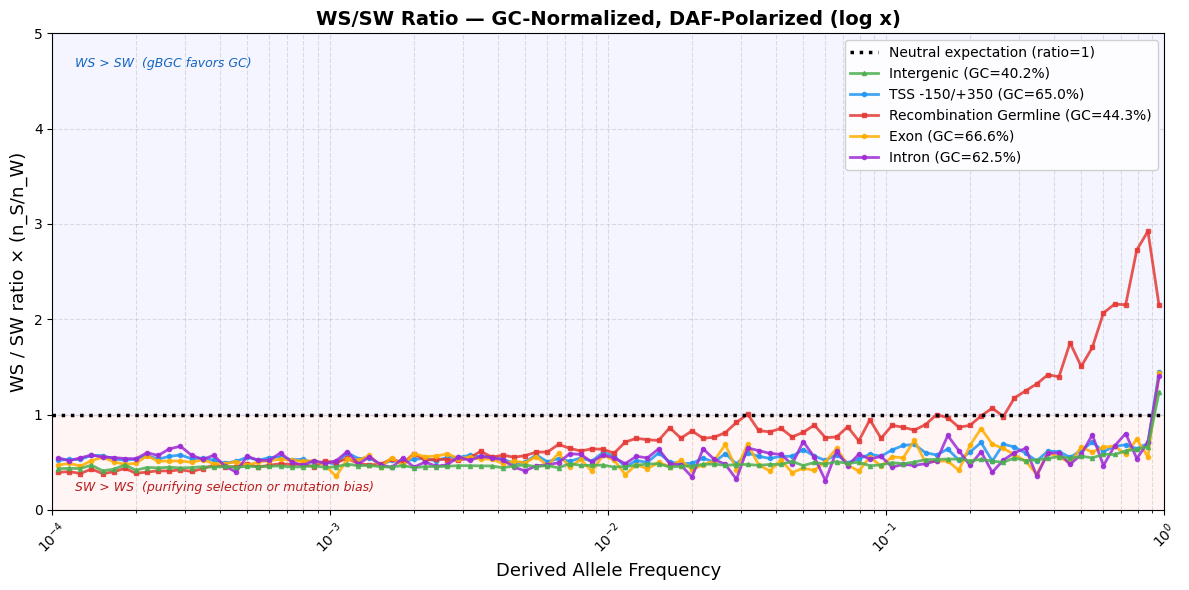

Saved: sfs_ratio_single_gcnorm_logx.tsv


In [19]:
def calculate_counts(freqs, bins):
    counts, bin_edges = np.histogram(freqs, bins=bins)
    bin_mids = (bin_edges[:-1] + bin_edges[1:]) / 2
    return bin_mids, counts


def plot_ratio_single(n_W_datasets=None, n_S_datasets=None,
                      n_W_ig=None, n_S_ig=None,
                      normalize_gc=False, bins=None,
                      title=None, output='sfs_ratio_single.pdf',
                      data_output=None, min_counts=5,
                      ylim=None, xscale='linear'):
    '''
    Single-panel WS/SW ratio across the full DAF spectrum.
    Saves PDF + PNG + TSV (the underlying per-bin counts and ratios).
    '''
    if bins is None:
        if xscale == 'log':
            bins = np.logspace(np.log10(0.0001), np.log10(1.0), 101)
        else:
            bins = np.linspace(0.0001, 1.0, 101)
    bin_mids = (bins[:-1] + bins[1:]) / 2
    if title is None:
        title = ('WS/SW Ratio — GC-Normalized' if normalize_gc
                 else 'WS/SW Ratio — Raw')
    records = []
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.axhline(y=1.0, color='black', linestyle=':', linewidth=2.5,
               label='Neutral expectation (ratio=1)', zorder=6)

    # Intergenic
    _, ig_sw = calculate_counts(ig_data['SW'], bins)
    _, ig_ws = calculate_counts(ig_data['WS'], bins)
    ig_mask  = (ig_sw > min_counts) & (ig_ws > min_counts)
    ig_ratio_plot = ig_ws[ig_mask] / ig_sw[ig_mask]
    if normalize_gc and n_W_ig is not None:
        gc_factor_ig = n_S_ig / n_W_ig
        ig_ratio_plot = ig_ratio_plot * gc_factor_ig
        ig_label = f'Intergenic (GC={100*n_S_ig/(n_W_ig+n_S_ig):.1f}%)'
    else:
        gc_factor_ig = 1.0
        ig_label = 'Intergenic'
    ax.plot(bin_mids[ig_mask], ig_ratio_plot,
            color=intergenic_color, linewidth=2, marker='^', markersize=3,
            label=ig_label, zorder=5, alpha=0.85)
    for k in range(len(bin_mids)):
        records.append({
            'dataset': 'Intergenic', 'bin_lo': bins[k], 'bin_hi': bins[k+1],
            'bin_mid': bin_mids[k], 'sw_count': int(ig_sw[k]), 'ws_count': int(ig_ws[k]),
            'ratio_raw': (ig_ws[k]/ig_sw[k]) if ig_sw[k] > 0 else np.nan,
            'gc_factor': gc_factor_ig,
            'ratio_plotted': ((ig_ws[k]/ig_sw[k]) * gc_factor_ig) if ig_sw[k] > 0 else np.nan,
            'plotted': bool(ig_mask[k]),
        })

    # Each TSS dataset
    for i, (data, label, color, marker) in enumerate(
            zip(tss_data, window_labels, window_colors, window_markers)):
        _, sw_c = calculate_counts(data['SW'], bins)
        _, ws_c = calculate_counts(data['WS'], bins)
        mask = (sw_c > min_counts) & (ws_c > min_counts)
        ratio_plot = ws_c[mask] / sw_c[mask]
        if normalize_gc and n_W_datasets is not None:
            nw, ns = n_W_datasets[i], n_S_datasets[i]
            gc_factor = ns / nw
            ratio_plot = ratio_plot * gc_factor
            lbl = f'{label} (GC={100*ns/(nw+ns):.1f}%)'
        else:
            gc_factor = 1.0
            lbl = label
        ax.plot(bin_mids[mask], ratio_plot,
                color=color, linewidth=2, marker=marker, markersize=3,
                label=lbl, zorder=3, alpha=0.85)
        for k in range(len(bin_mids)):
            records.append({
                'dataset': label, 'bin_lo': bins[k], 'bin_hi': bins[k+1],
                'bin_mid': bin_mids[k], 'sw_count': int(sw_c[k]), 'ws_count': int(ws_c[k]),
                'ratio_raw': (ws_c[k]/sw_c[k]) if sw_c[k] > 0 else np.nan,
                'gc_factor': gc_factor,
                'ratio_plotted': ((ws_c[k]/sw_c[k]) * gc_factor) if sw_c[k] > 0 else np.nan,
                'plotted': bool(mask[k]),
            })

    ax.axhspan(1.0, 999, alpha=0.04, color='blue')
    ax.axhspan(0.0, 1.0, alpha=0.04, color='red')
    ax.annotate('WS > SW  (gBGC favors GC)',
                xy=(0.02, 0.93), xycoords='axes fraction',
                fontsize=9, color='#1565C0', style='italic')
    ax.annotate('SW > WS  (purifying selection or mutation bias)',
                xy=(0.02, 0.04), xycoords='axes fraction',
                fontsize=9, color='#B71C1C', style='italic')
    ax.set_xlabel('Derived Allele Frequency', fontsize=13)
    ax.set_ylabel('WS / SW ratio' + (' × (n_S/n_W)' if normalize_gc else ''),
                  fontsize=13)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlim(bins[0], bins[-1])
    if xscale == 'log':
        ax.set_xscale('log')
    else:
        ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    ax.tick_params(axis='x', rotation=45, labelsize=10)
    ax.grid(True, which='both', linestyle='--', alpha=0.4)
    ax.legend(fontsize=10, framealpha=0.9, loc='upper right')
    if ylim is not None:
        ax.set_ylim(ylim)
    plt.tight_layout()
    plt.savefig(output, bbox_inches='tight', dpi=300)
    plt.savefig(output.replace('.pdf', '.png'), bbox_inches='tight', dpi=150)
    print(f"Saved: {output}")
    plt.show()

    if data_output is None:
        base, _ = os.path.splitext(output)
        data_output = base + '.tsv'
    pd.DataFrame(records).to_csv(data_output, sep='\t', index=False)
    print(f"Saved: {data_output}")


# Final figure: GC-normalized WS/SW ratio with log-x DAF axis.
plot_ratio_single(
    normalize_gc = True,
    n_W_datasets = n_W_list,
    n_S_datasets = n_S_list,
    n_W_ig       = n_W_ig,
    n_S_ig       = n_S_ig,
    title        = 'WS/SW Ratio — GC-Normalized, DAF-Polarized (log x)',
    output       = 'sfs_ratio_single_gcnorm_logx.pdf',
    ylim         = (0.0, 5.0),
    xscale       = 'log',
)

## 8. Estimate background gBGC

Two-parameter fit (B = gBGC strength, c = baseline WS/SW ratio)
Region                          n_WS       n_SW   B_MLE            95% CI    c_MLE
Intergenic                 3,954,520  4,551,398   0.466  [0.438, 0.493]    0.669
TSS -150/+350                384,674  1,246,051   0.334  [0.235, 0.433]    0.289
Recombination Germline       457,659    586,712   2.449  [2.380, 2.518]    0.613
Exon                         138,914    486,688   0.355  [0.179, 0.527]    0.253
Intron                       105,291    320,434   0.219  [0.038, 0.397]    0.320

Saved: gBGC_B_estimates.pdf / .png


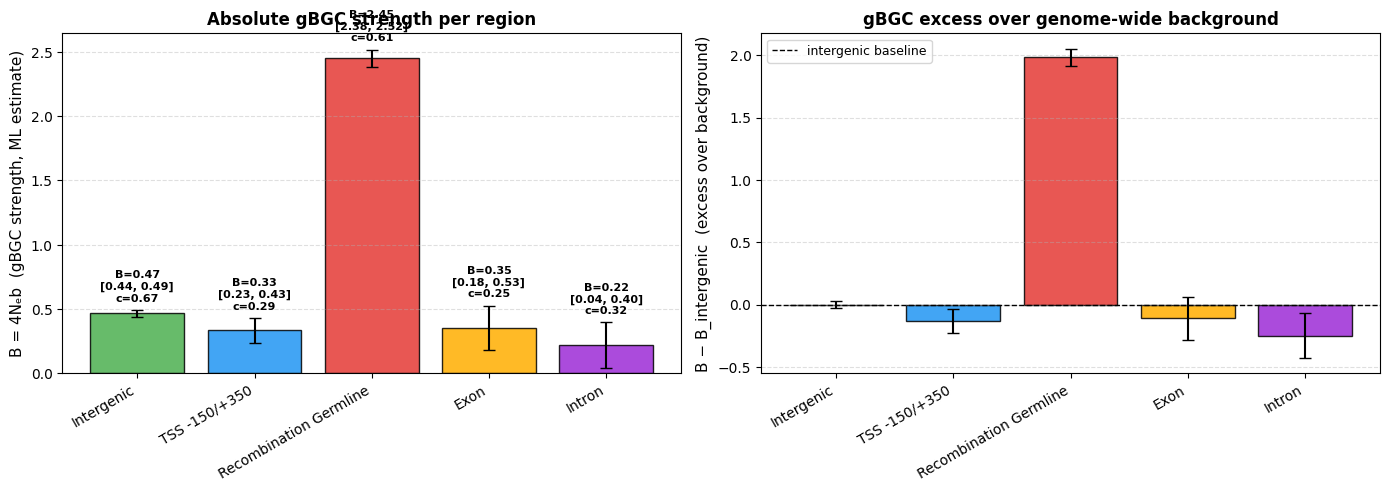

Saved: gBGC_B_likelihood_profiles.pdf / .png


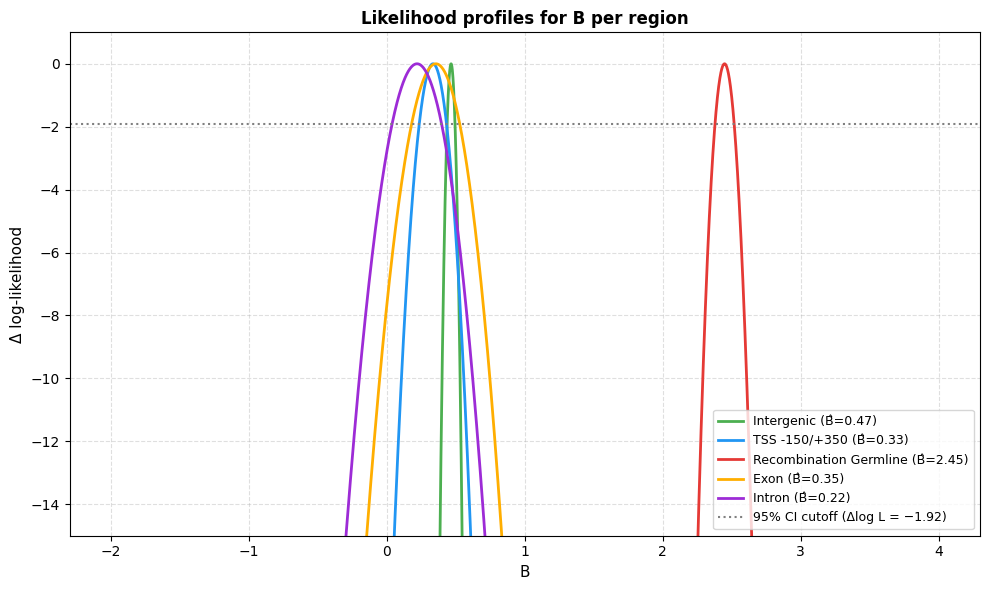


Saved: gBGC_B_estimates.tsv
                Region  B_MLE  B_lower_95  B_upper_95  excess_vs_intergenic
            Intergenic 0.4660      0.4375      0.4930                0.0000
         TSS -150/+350 0.3340      0.2350      0.4330               -0.1320
Recombination Germline 2.4490      2.3800      2.5180                1.9830
                  Exon 0.3550      0.1795      0.5275               -0.1110
                Intron 0.2185      0.0385      0.3970               -0.2475


In [29]:
# =============================================================================
# CELL — Two-parameter B fit accounting for mutation-rate baseline.
# Replaces the previous fit_B function (third version).
#
# Model: at DAF x under gBGC strength B and baseline mutation+availability ratio c,
#   p_WS(x | B, c) = c·g(x;+B) / (c·g(x;+B) + g(x;-B))
# where g(x;B) = (1-exp(-B(1-x))) / (1-exp(-B)) is the gBGC SFS shape.
#
# Parameter c = (n_W · μ_W→S) / (n_S · μ_S→W) is the expected WS/SW count ratio
# at B=0 in that region. It captures both mutation-rate bias (CpG hypermutability
# producing excess SW) and base-pair availability. We fit c jointly with B so
# the gBGC parameter B reflects only the *DAF-dependent shape change*, not the
# baseline asymmetry.
# =============================================================================

from scipy.optimize import minimize
from scipy.special import expm1


def g_shape(x, B):
    """gBGC SFS shape factor."""
    x = np.asarray(x, dtype=float)
    if abs(B) < 1e-8:
        return np.ones_like(x)
    return -expm1(-B * (1.0 - x)) / -expm1(-B)


def p_ws_two_param(x, B, log_c):
    """Expected WS proportion at DAF x with gBGC B and log baseline log_c."""
    c = np.exp(log_c)
    gws = g_shape(x, +B)
    gsw = g_shape(x, -B)
    return (c * gws) / (c * gws + gsw)


def fit_B(daf_ws, daf_sw, n_bins=30, xmin=1e-4, xmax=0.95, min_count_per_bin=5,
          B_grid_range=(-2.0, 4.0), n_B_grid=4001):
    """
    Two-parameter ML fit of B and c (baseline mutation+availability ratio).
    Returns (B_MLE, B_lower_95, B_upper_95, B_grid, profile_log_likelihoods, c_MLE).
    The profile log-likelihood at each B is taken by maximizing over log_c.
    """
    # Bin
    bins = np.logspace(np.log10(xmin), np.log10(xmax), n_bins + 1)
    ws_in = daf_ws[(daf_ws >= xmin) & (daf_ws <= xmax)]
    sw_in = daf_sw[(daf_sw >= xmin) & (daf_sw <= xmax)]
    ws_c, _ = np.histogram(ws_in, bins=bins)
    sw_c, _ = np.histogram(sw_in, bins=bins)
    bin_mids = np.sqrt(bins[:-1] * bins[1:])

    keep = (ws_c >= min_count_per_bin) & (sw_c >= min_count_per_bin)
    ws_c, sw_c, mids = ws_c[keep], sw_c[keep], bin_mids[keep]
    if len(ws_c) < 4:
        print(f"  Warning: only {len(ws_c)} usable bins")

    def neg_ll(B, log_c):
        p = p_ws_two_param(mids, B, log_c)
        p = np.clip(p, 1e-10, 1 - 1e-10)
        return -np.sum(ws_c * np.log(p) + sw_c * np.log(1 - p))

    # Joint MLE
    def neg_ll_joint(params):
        return neg_ll(params[0], params[1])
    res = minimize(neg_ll_joint, x0=[0.0, np.log(ws_c.sum() / sw_c.sum())],
                   method='Nelder-Mead', options={'xatol': 1e-4, 'fatol': 1e-4})
    B_mle, log_c_mle = res.x

    # Profile likelihood over B (optimize c at each B for 95% CI)
    B_grid = np.linspace(B_grid_range[0], B_grid_range[1], n_B_grid)
    profile_lls = np.zeros(len(B_grid))   # was: np.zeros(n_B_grid)
    for i, B in enumerate(B_grid):
        # Optimize log_c at this B
        sub = minimize(lambda lc: neg_ll(B, lc[0]),
                       x0=[log_c_mle], method='Nelder-Mead',
                       options={'xatol': 1e-4, 'fatol': 1e-4})
        profile_lls[i] = -sub.fun

    ll_max_grid = profile_lls.max()
    B_mle_grid  = B_grid[profile_lls.argmax()]
    in_ci = profile_lls >= (ll_max_grid - 1.92)
    B_lo = B_grid[in_ci].min()
    B_hi = B_grid[in_ci].max()

    return B_mle_grid, B_lo, B_hi, B_grid, profile_lls, np.exp(log_c_mle)


# Re-run on every region
results = {}
print(f"Two-parameter fit (B = gBGC strength, c = baseline WS/SW ratio)")
print(f"{'Region':<25s} {'n_WS':>10s} {'n_SW':>10s} {'B_MLE':>7s}  "
      f"{'95% CI':>16s}  {'c_MLE':>7s}")

B, lo, hi, grid, lls, c = fit_B(ig_data['WS'], ig_data['SW'])
results['Intergenic'] = (B, lo, hi, grid, lls, c)
print(f"{'Intergenic':<25s} {len(ig_data['WS']):>10,} {len(ig_data['SW']):>10,} "
      f"{B:>7.3f}  [{lo:>5.3f}, {hi:>5.3f}]  {c:>7.3f}")

for i, label in enumerate(window_labels):
    B, lo, hi, grid, lls, c = fit_B(tss_data[i]['WS'], tss_data[i]['SW'])
    results[label] = (B, lo, hi, grid, lls, c)
    print(f"{label:<25s} {len(tss_data[i]['WS']):>10,} {len(tss_data[i]['SW']):>10,} "
          f"{B:>7.3f}  [{lo:>5.3f}, {hi:>5.3f}]  {c:>7.3f}")


# ---- Visualize: bar chart of B with 95% CI; "excess" relative to intergenic ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

regions_in_order = ['Intergenic'] + window_labels
colors_in_order  = [intergenic_color] + window_colors

# Panel 1: absolute B
B_mles = [results[r][0] for r in regions_in_order]
B_los  = [results[r][1] for r in regions_in_order]
B_his  = [results[r][2] for r in regions_in_order]
err_lo = [m - l for m, l in zip(B_mles, B_los)]
err_hi = [h - m for h, m in zip(B_his, B_mles)]
c_mles = [results[r][5] for r in regions_in_order]

x_pos = np.arange(len(regions_in_order))
ax1.bar(x_pos, B_mles, yerr=[err_lo, err_hi], color=colors_in_order,
        alpha=0.85, edgecolor='black', linewidth=1, capsize=4)
ax1.axhline(0, color='black', linewidth=0.6)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(regions_in_order, rotation=30, ha='right', fontsize=10)
ax1.set_ylabel('B = 4Nₑb  (gBGC strength, ML estimate)', fontsize=11)
ax1.set_title('Absolute gBGC strength per region', fontsize=12, fontweight='bold')
ax1.grid(True, axis='y', linestyle='--', alpha=0.4)
for i, (m, l, h, c) in enumerate(zip(B_mles, B_los, B_his, c_mles)):
    ax1.annotate(f'B={m:.2f}\n[{l:.2f}, {h:.2f}]\nc={c:.2f}',
                 xy=(i, h), xytext=(0, 6), textcoords='offset points',
                 ha='center', fontsize=8, fontweight='bold')

# Panel 2: excess over intergenic background
B_ig = results['Intergenic'][0]
excess_mles = [results[r][0] - B_ig for r in regions_in_order]
excess_los  = [results[r][1] - B_ig for r in regions_in_order]
excess_his  = [results[r][2] - B_ig for r in regions_in_order]
err_lo_x = [m - l for m, l in zip(excess_mles, excess_los)]
err_hi_x = [h - m for h, m in zip(excess_his, excess_mles)]

ax2.bar(x_pos, excess_mles, yerr=[err_lo_x, err_hi_x], color=colors_in_order,
        alpha=0.85, edgecolor='black', linewidth=1, capsize=4)
ax2.axhline(0, color='black', linewidth=1, linestyle='--',
            label='intergenic baseline')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(regions_in_order, rotation=30, ha='right', fontsize=10)
ax2.set_ylabel('B − B_intergenic  (excess over background)', fontsize=11)
ax2.set_title('gBGC excess over genome-wide background', fontsize=12, fontweight='bold')
ax2.grid(True, axis='y', linestyle='--', alpha=0.4)
ax2.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('gBGC_B_estimates.pdf', bbox_inches='tight', dpi=300)
plt.savefig('gBGC_B_estimates.png', bbox_inches='tight', dpi=150)
print(f"\nSaved: gBGC_B_estimates.pdf / .png")
plt.show()


# ---- Also save likelihood profiles for inspection ----
fig, ax = plt.subplots(figsize=(10, 6))
for region, color in zip(regions_in_order, colors_in_order):
    B, lo, hi, grid, lls, _ = results[region]
    ax.plot(grid, lls - lls.max(), color=color, linewidth=2, label=f'{region} (B̂={B:.2f})')
ax.axhline(-1.92, color='gray', linestyle=':', label='95% CI cutoff (Δlog L = −1.92)')
ax.set_xlabel('B', fontsize=11)
ax.set_ylabel('Δ log-likelihood', fontsize=11)
ax.set_title('Likelihood profiles for B per region', fontsize=12, fontweight='bold')
ax.set_ylim(-15, 1)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('gBGC_B_likelihood_profiles.pdf', bbox_inches='tight', dpi=300)
plt.savefig('gBGC_B_likelihood_profiles.png', bbox_inches='tight', dpi=150)
print(f"Saved: gBGC_B_likelihood_profiles.pdf / .png")
plt.show()


# ---- Save numerical results to TSV ----
results_df = pd.DataFrame([
    {'Region': r, 'B_MLE': results[r][0], 'B_lower_95': results[r][1],
     'B_upper_95': results[r][2], 'excess_vs_intergenic': results[r][0] - B_ig}
    for r in regions_in_order
])
results_df.to_csv('gBGC_B_estimates.tsv', sep='\t', index=False, float_format='%.4f')
print(f"\nSaved: gBGC_B_estimates.tsv")
print(results_df.to_string(index=False))